In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,GridSearchCV

from sklearn.preprocessing import LabelEncoder,MinMaxScaler

from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier,GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import ConfusionMatrixDisplay,classification_report,confusion_matrix
from sklearn.metrics import accuracy_score

from imblearn.over_sampling import SMOTE

import pickle

In [6]:
df=pd.read_csv(r"C:\Users\ACER\Downloads\credit_card_fraud_10k.csv")
df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


In [8]:
df.shape

(10000, 10)

In [9]:
df.describe()

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,175.949849,11.593300,0.097800,0.085700,61.798900,2.008900,43.468700,0.015100
std,2886.89568,175.392827,6.922708,0.297059,0.279935,21.487053,1.432559,14.979147,0.121957
min,1.00000,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,18.000000,0.000000
25%,2500.75000,50.905000,6.000000,0.000000,0.000000,43.000000,1.000000,30.000000,0.000000
50%,5000.50000,122.095000,12.000000,0.000000,0.000000,62.000000,2.000000,44.000000,0.000000
75%,7500.25000,242.480000,18.000000,0.000000,0.000000,80.000000,3.000000,56.000000,0.000000
max,10000.00000,1471.040000,23.000000,1.000000,1.000000,99.000000,9.000000,69.000000,1.000000


In [10]:
df.isnull().sum()

transaction_id         0
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64

In [11]:
le=LabelEncoder()
df["merchant_category"]=le.fit_transform(df["merchant_category"])


In [12]:
df.drop("transaction_id",axis=1,inplace=True)

In [13]:
x=df.drop(["is_fraud"],axis=1)
y=df["is_fraud"]

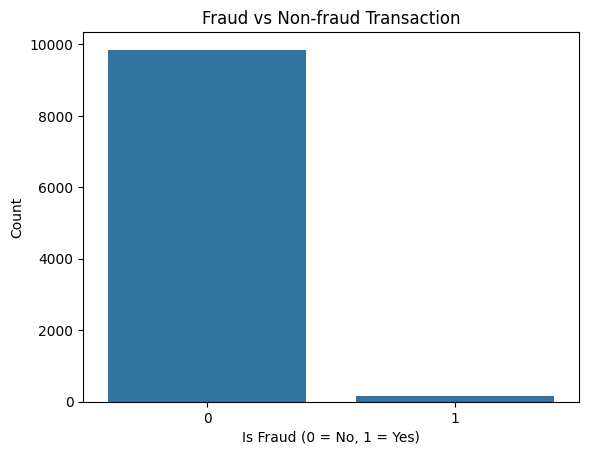

In [14]:
sns.countplot(x="is_fraud",data=df)
plt.title("Fraud vs Non-fraud Transaction")
plt.xlabel("Is Fraud (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

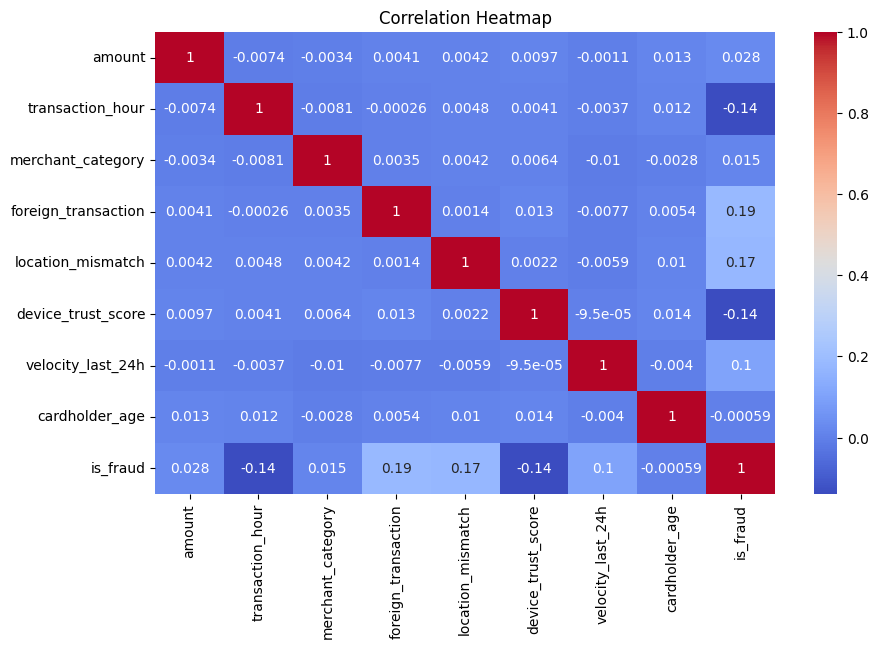

In [15]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

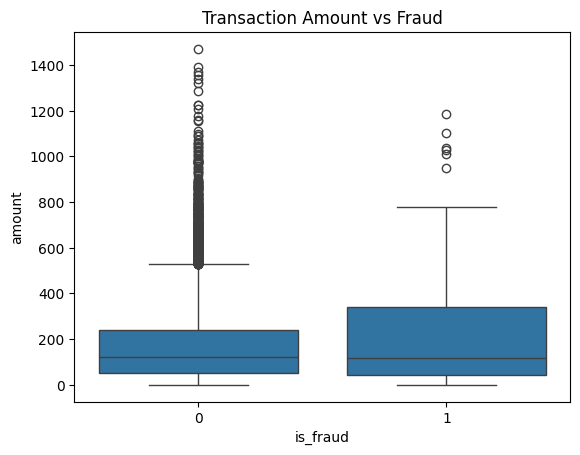

In [16]:
sns.boxplot(x='is_fraud', y='amount', data=df)
plt.title("Transaction Amount vs Fraud")
plt.show()

In [17]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [18]:


sc = MinMaxScaler()
x_train = sc.fit_transform(x_train)
x_test_scaled = sc.transform(x_test)

In [ ]:
x=XGBClassifier()
gr=GradientBoostingClassifier()
ad=AdaBoostClassifier()
d=DecisionTreeClassifier()
g=GaussianNB()
svc=SVC()
knn=KNeighborsClassifier(n_neighbors=3)
rfc = RandomForestClassifier(class_weight='balanced')
l=[knn,svc,g,d,gr,ad]
for i in l:
    print(i)
    i.fit(x_train,y_train) 
    y_pred=i.predict(x_test_scaled)

    print(classification_report(y_test,y_pred))


KNeighborsClassifier(n_neighbors=3)
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1969
           1       0.75      0.39      0.51        31

    accuracy                           0.99      2000
   macro avg       0.87      0.69      0.75      2000
weighted avg       0.99      0.99      0.99      2000

SVC()
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1969
           1       1.00      0.32      0.49        31

    accuracy                           0.99      2000
   macro avg       0.99      0.66      0.74      2000
weighted avg       0.99      0.99      0.99      2000

GaussianNB()
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1969
           1       0.44      0.71      0.54        31

    accuracy                           0.98      2000
   macro avg       0.72      0.85      0.77      2000
weighted avg       

In [20]:
df['is_fraud'].value_counts()

is_fraud
0    9849
1     151
Name: count, dtype: int64

In [ ]:
sm = SMOTE(random_state=42)
x_res, y_res = sm.fit_resample(x_train, y_train)

In [ ]:
x=XGBClassifier()
gr=GradientBoostingClassifier()
ad=AdaBoostClassifier()
d=DecisionTreeClassifier()
g=GaussianNB()
svc=SVC()
knn=KNeighborsClassifier(n_neighbors=3)
rfc = RandomForestClassifier(class_weight='balanced')
l=[knn,svc,g,d,gr,ad]
for model in l:
    print("\n==============================")
    print(model)
    
    # Train
    model.fit(x_res, y_res)
    
    # Predict on TEST data (NOT train)
    y_pred = model.predict(x_test_scaled)
    
    # Evaluation
    print(classification_report(y_test, y_pred))



KNeighborsClassifier(n_neighbors=3)
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1969
           1       0.49      0.84      0.62        31

    accuracy                           0.98      2000
   macro avg       0.74      0.91      0.81      2000
weighted avg       0.99      0.98      0.99      2000


SVC()
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1969
           1       0.42      0.81      0.55        31

    accuracy                           0.98      2000
   macro avg       0.71      0.89      0.77      2000
weighted avg       0.99      0.98      0.98      2000


GaussianNB()
              precision    recall  f1-score   support

           0       1.00      0.91      0.95      1969
           1       0.13      0.90      0.23        31

    accuracy                           0.91      2000
   macro avg       0.56      0.90      0.59      2000
weighted avg    

In [23]:
models = {
    "XGB": XGBClassifier(),
    "GBoost": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "DecisionTree": DecisionTreeClassifier(random_state=1),
    "NaiveBayes": GaussianNB(),
    "RandomForest": RandomForestClassifier(class_weight='balanced'),
    #"SVC": SVC(class_weight='balanced'),
    "KNN": KNeighborsClassifier()
}

In [24]:
param_grids = {

    "XGB": {
        "n_estimators": [50, 100],
        "max_depth": [3, 5],
        "learning_rate": [0.01, 0.1]
    },

    "GBoost": {
        "n_estimators": [50, 100],
        "learning_rate": [0.01, 0.1],
        "max_depth": [3, 5]
    },

    "AdaBoost": {
        "n_estimators": [50, 100],
        "learning_rate": [0.01, 0.1]
    },

    "DecisionTree": {
        "max_depth": [None, 5, 10],
        "min_samples_split": [2, 5, 10]
    },

    "NaiveBayes": {
        "var_smoothing": [1e-9, 1e-8, 1e-7]
    },

    "RandomForest": {
        "n_estimators": [100, 200],
        "max_depth": [None, 10],
        "min_samples_split": [2, 5]
    
    },

    "KNN": {
        "n_neighbors": [3, 5, 7],
        "weights": ["uniform", "distance"],
        "metric": ["euclidean", "manhattan"]
    }
}


In [25]:
best_models = {}

for name, model in models.items():
    print(f"Running GridSearch for {name}...")

    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )

    grid.fit(x_train, y_train)

    best_models[name] = grid.best_estimator_

    print(f"Best Params for {name}: {grid.best_params_}")
    print(f"Best Score for {name}: {grid.best_score_}")
    print("-" * 50)

Running GridSearch for XGB...
Best Params for XGB: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
Best Score for XGB: 0.9983749999999999
--------------------------------------------------
Running GridSearch for GBoost...
Best Params for GBoost: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best Score for GBoost: 0.998625
--------------------------------------------------
Running GridSearch for AdaBoost...
Best Params for AdaBoost: {'learning_rate': 0.1, 'n_estimators': 100}
Best Score for AdaBoost: 0.9858749999999998
--------------------------------------------------
Running GridSearch for DecisionTree...
Best Params for DecisionTree: {'max_depth': None, 'min_samples_split': 10}
Best Score for DecisionTree: 0.9981249999999999
--------------------------------------------------
Running GridSearch for NaiveBayes...
Best Params for NaiveBayes: {'var_smoothing': 1e-09}
Best Score for NaiveBayes: 0.9814999999999999
--------------------------------------------------

In [26]:

x=XGBClassifier( learning_rate= 0.1, max_depth= 5, n_estimators= 100)
gr=GradientBoostingClassifier(learning_rate=0.1, max_depth= 5, n_estimators= 100)
ad=AdaBoostClassifier(learning_rate= 0.1, n_estimators= 100)
d=DecisionTreeClassifier(max_depth= None, min_samples_split=2)
g=GaussianNB(var_smoothing=1e-09)
svc=SVC()
knn=KNeighborsClassifier(n_neighbors=3,weights='distance')
rfc = RandomForestClassifier(max_depth=None,min_samples_split=2,n_estimators=200)
l=[knn,svc,g,d,gr,ad]
for model in l:
    print(model)
    
    # Train
    model.fit(x_res, y_res)
    
    # Predict on TEST data (NOT train)
    y_pred = model.predict(x_test_scaled)
    
    # Evaluation
    print(classification_report(y_test, y_pred))


KNeighborsClassifier(n_neighbors=3, weights='distance')
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1969
           1       0.49      0.84      0.62        31

    accuracy                           0.98      2000
   macro avg       0.74      0.91      0.81      2000
weighted avg       0.99      0.98      0.99      2000

SVC()
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1969
           1       0.42      0.81      0.55        31

    accuracy                           0.98      2000
   macro avg       0.71      0.89      0.77      2000
weighted avg       0.99      0.98      0.98      2000

GaussianNB()
              precision    recall  f1-score   support

           0       1.00      0.91      0.95      1969
           1       0.13      0.90      0.23        31

    accuracy                           0.91      2000
   macro avg       0.56      0.90      0.59      2000

In [27]:
final_model=GradientBoostingClassifier(learning_rate=0.1, max_depth= 5, n_estimators= 100)

In [28]:
final_model.fit(x_res, y_res)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,5
,min_impurity_decrease,0.0
,init,None


In [29]:
y_pred=final_model.predict(x_test_scaled)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(2000,))

In [30]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.998


In [31]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[1966    3]
 [   1   30]]


In [32]:
cr = classification_report(y_test, y_pred)
print("\nClassification Report:\n", cr)


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1969
           1       0.91      0.97      0.94        31

    accuracy                           1.00      2000
   macro avg       0.95      0.98      0.97      2000
weighted avg       1.00      1.00      1.00      2000



In [34]:
with open("model.pkl", "wb") as file:
    pickle.dump(model, file)

In [35]:
with open("encoder.pkl", "wb") as f:
    pickle.dump(le, f)